# Multilayer Perceptron (MLP) Analysis

## Overview
A Multilayer Perceptron is a feedforward artificial neural network. It consists of at least three layers of nodes: an input layer, a hidden layer, and an output layer. 

## The XOR Challenge
We will demonstrate the MLP's ability to solve the **XOR (Exclusive OR)** problem, which is famously impossible for linear classifiers like the Perceptron to solve.

| Input 1 | Input 2 | Output (XOR) |
|:-------:|:-------:|:------------:|
|    0    |    0    |      0       |
|    0    |    1    |      1       |
|    1    |    0    |      1       |
|    1    |    1    |      0       |

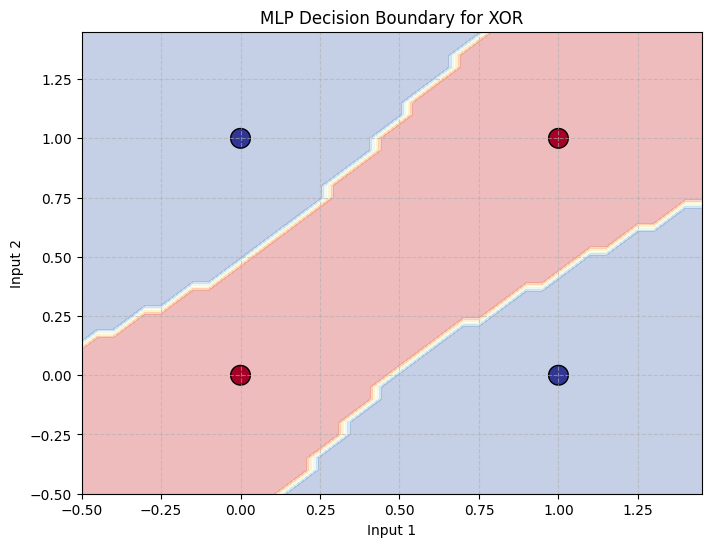

Predictions for XOR inputs:
[[0]
 [1]
 [1]
 [0]]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mlpackage import MultilayerPerceptron

# 1. Define XOR Data
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([[0], [1], [1], [0]])

# 2. Train the MLP
# Using 4 hidden neurons to allow for complex decision boundaries
model = MultilayerPerceptron(input_size=2, hidden_size=4, output_size=1, learning_rate=0.5, n_iters=10000)
model.fit(X, y)

# 3. Create a grid to visualize the "Thinking" of the network
x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

# Get predictions for every point in the grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 4. Plotting
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), s=200, edgecolors='k', cmap='RdYlBu')
plt.title("MLP Decision Boundary for XOR")
plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("Predictions for XOR inputs:")
print(model.predict(X))